## RAG Pipeline - Data Ingestion to Vector DB Pipeline

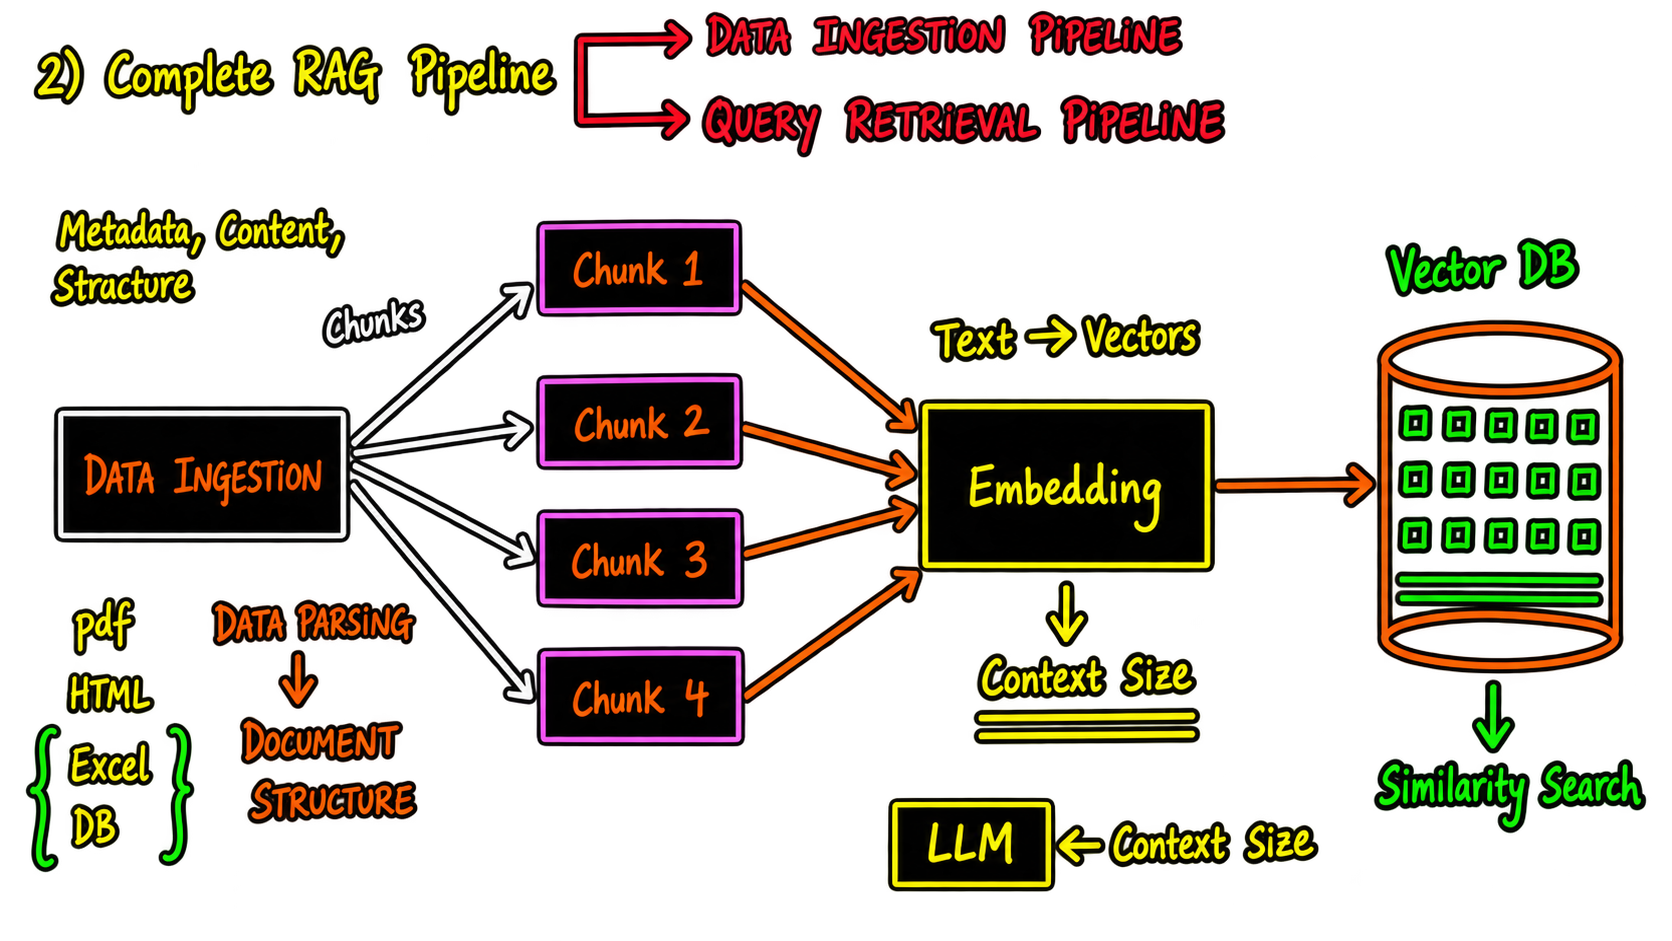

In [1]:
import os
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path

C:\Users\ASUS\AppData\Local\Temp\ipykernel_40692\3933654057.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
d:\AI Dev\Generative AI\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Data Ingestion

In [2]:
## it reads the all the pdf files inside a folder
def process_all_pdfs(pdf_directory):
    '''Process all PDF files in a directory'''
    all_documents = []
    pdf_dir = Path(pdf_directory)

    #Find all PDF files recursively
    pdf_files = list(pdf_dir.glob("**/*.pdf"))

    print(f"Found {len(pdf_files)} PDF files to process")

    for pdf_file in pdf_files:
        print(f"\nProcessing: {pdf_file.name}")
        try:
            loader = PyPDFLoader(str(pdf_file))
            documents = loader.load()

            ## Adding source information to metadata
            for doc in documents:
                doc.metadata['source_file'] = pdf_file.name
                doc.metadata['file_type'] = 'pdf'

            all_documents.extend(documents) #we will store all documents after reading into this list
            print(f"✅ Loaded {len(documents)} Pages")
        
        except Exception as e:
            print(f"❌ Error: {e}")
    print(f"\nTotal documents loaded: {len(all_documents)}")
    return all_documents

    # Process all PDF's in the directory
all_pdf_documents = process_all_pdfs("../data")

Found 5 PDF files to process

Processing: APIP(FINALVERSION).pdf
✅ Loaded 6 Pages

Processing: attention.pdf
✅ Loaded 1 Pages

Processing: embeddings.pdf
✅ Loaded 1 Pages

Processing: objectdetection.pdf
✅ Loaded 1 Pages

Processing: proposal.pdf
✅ Loaded 1 Pages

Total documents loaded: 10


In [3]:
all_pdf_documents ## list of documents

[Document(metadata={'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-08-20T10:15:15+05:30', 'author': '', 'moddate': '2026-08-20T10:15:15+05:30', 'title': 'Microsoft PowerPoint - Review - PPT - Template.pptx', 'source': '..\\data\\pdf\\APIP(FINALVERSION).pdf', 'total_pages': 6, 'page': 0, 'page_label': '1', 'source_file': 'APIP(FINALVERSION).pdf', 'file_type': 'pdf'}, page_content='FACULTY OF ENGINEERING AND TECHNOLOGY\nSCHOOL OF COMPUTATIONAL ENGINEERING\nDEPARTMENT OF AIML\n1\nAgentic PharmaCo Intelligent Platform(APIP)\nBatch Number: 11\nSAILESH CHIKKAM (TU6230105111007)\nJAYANTH. K (TU6230105111012)\nN. MOHAN SAI REDDY (TU6230105111027)                       \nSupervisor Name: DR.ANANDHI.M\nDesignation: ASP/CSE\nTime: 10:00 A.MDate: 20-08-2026\nPROJECT PHASE – I\nZeroth Review'),
 Document(metadata={'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-08-20T10:15:15+05:30', 'author': '', 'moddate': '2026-08-20T10:15:15+05:

### 2. chunking  ---  Text splitting get into chunks

In [4]:
## Text splitting get into chunks

def split_documents(documents, chunk_size = 1000, chunk_overlap = 200):
    """Split documents into smaller chunks for better RAG performance"""
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", "", ""]
    )
    split_docs = text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks")

    # show example of a chunk
    if split_docs:
        print(f"\nExample chunk: ")
        print(f"Content: {split_docs[0].page_content[:200]}...")
        print(f"Metadata: {split_docs[0].metadata}")

    return split_docs

In [5]:
### here we should pass list of documents
chunks = split_documents(all_pdf_documents)
chunks

Split 10 documents into 17 chunks

Example chunk: 
Content: FACULTY OF ENGINEERING AND TECHNOLOGY
SCHOOL OF COMPUTATIONAL ENGINEERING
DEPARTMENT OF AIML
1
Agentic PharmaCo Intelligent Platform(APIP)
Batch Number: 11
SAILESH CHIKKAM (TU6230105111007)
JAYANTH. K...
Metadata: {'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-08-20T10:15:15+05:30', 'author': '', 'moddate': '2026-08-20T10:15:15+05:30', 'title': 'Microsoft PowerPoint - Review - PPT - Template.pptx', 'source': '..\\data\\pdf\\APIP(FINALVERSION).pdf', 'total_pages': 6, 'page': 0, 'page_label': '1', 'source_file': 'APIP(FINALVERSION).pdf', 'file_type': 'pdf'}


[Document(metadata={'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-08-20T10:15:15+05:30', 'author': '', 'moddate': '2026-08-20T10:15:15+05:30', 'title': 'Microsoft PowerPoint - Review - PPT - Template.pptx', 'source': '..\\data\\pdf\\APIP(FINALVERSION).pdf', 'total_pages': 6, 'page': 0, 'page_label': '1', 'source_file': 'APIP(FINALVERSION).pdf', 'file_type': 'pdf'}, page_content='FACULTY OF ENGINEERING AND TECHNOLOGY\nSCHOOL OF COMPUTATIONAL ENGINEERING\nDEPARTMENT OF AIML\n1\nAgentic PharmaCo Intelligent Platform(APIP)\nBatch Number: 11\nSAILESH CHIKKAM (TU6230105111007)\nJAYANTH. K (TU6230105111012)\nN. MOHAN SAI REDDY (TU6230105111027)                       \nSupervisor Name: DR.ANANDHI.M\nDesignation: ASP/CSE\nTime: 10:00 A.MDate: 20-08-2026\nPROJECT PHASE – I\nZeroth Review'),
 Document(metadata={'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-08-20T10:15:15+05:30', 'author': '', 'moddate': '2026-08-20T10:15:15+05:

### 3. Embedding & VectorStoreDB

In [6]:
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
import uuid
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
class EmbeddingManager:
    '''Handles document embedding generation using SentenceTransformer'''
    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):
        '''
        Intialize the embedding manager
        
        Args:
            model_name: HuggingFace model name for sentence embeddings
        '''
        self.model_name = model_name
        self.model = None
        self._load_model() ##function loads "all_MiniLM-L6-v2"

    ## protected function _load_model()
    def _load_model(self):
        '''Load the SentenceTransformer model'''
        try:
            print(f"Loading embedding model: {self.model_name}")
            self.model = SentenceTransformer(self.model_name) ## main
            print(f"Model loaded sunccefully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")
        except Exception as e:
            print(f"Error in loading model {self.model_name}: {e}")
            raise

    ## to generate embeddings
    def generate_embeddings(self, texts: List[str]) -> np.ndarray:
            '''
            Generate embeddings for a list of texts

            Args:
            texts: List of text strings to embed

            Returns:
            numpy array of embeddings with shape (len(texts), embedding_dim)
            '''
            if not self.model:
                raise ValueError("model not loaded")
            print(f"Generating Embeddings for {len(texts)} texts...")
            embeddings = self.model.encode(texts, show_progress_bar = True) ## main
            print(f"Generated embeddings with shape: {embeddings.shape}")
            return embeddings

## initialize the embedding manaager
embedding_manager = EmbeddingManager()
embedding_manager

Loading embedding model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1329.84it/s]


Model loaded sunccefully. Embedding dimension: 384


C:\Users\ASUS\AppData\Local\Temp\ipykernel_40692\1624420428.py:20: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model loaded sunccefully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")


### 4. VectorStoreDB

In [ ]:
class VectorStore:
    '''Manages document embeddings in aChromaDB vector store'''

    def __init__(self, collection_name: str = "pdf_documents", persist_directory: str = "../data/vector_store"):
        '''
        Initialize the vector store
        
        Args:
        collection_name: Name of the ChromaDB collection
        persist_directory: Directory to persists the vector store
        '''

        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.client = None
        self.collection = None
        self._initialize_store()

        ##ChromaDB
    def _initialize_store(self):
        '''Initialize ChromaDB client and collection'''
        try:
            #Create Persistent ChromaDB client
            os.makedirs(self.persist_directory, exist_ok=True)
            self.client = chromadb.PersistentClient(path = self.persist_directory)

            # Get or create collection
            ## where we are gng to store the vectors after embedding in vector store
            self.collection = self.client.get_or_create_collection(
                name=self.collection_nam,
                metadata={"description": "PDF document embeddings for RAG"}
            )

            print(f"Vector store initialized. Collection: {self.collection_name}")
            print(f"Existing Documents in collection: {self.collection.count}")
        except Exception as e:
            print(f"Error in initializing vector store: {e}")
            raise

    def add_documents(self, documents: List[Any], embeddings: np.ndarray):
        '''
        Add documents and their embeddings to the vector store
        
        Args:
            documents: List of Langchain documents
            embeddings: Corresponding embeddings for the documents
        '''